<a href="https://colab.research.google.com/github/Rafael-Diaz-O/fundamentos_IA_algoritmos_machine_learning/blob/main/Fundamentos_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Machine learning

##Aprendizaje supervizado clasificación

In [ ]:
#Calsificador con arboles de desicion

#Importar las bibliotecas necesarias
from sklearn.datasets import load_iris #Una libreria de flores
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

#Cargar el dataset Iris
iris = load_iris()
X = iris.data  # Características (largo y ancho de pétalos y sépalos)
y = iris.target  # Rótulos (especies de flores)

#Dividir los datos para entrenamiento y para prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
#En test_size estamos guardando ese 30 % de la informacion para luego usarla para hacer pruebas y ver como se comporta el modelo con nueva información


#Entrenar el modelo
model = DecisionTreeClassifier() #Creamo un arbol de decision
model.fit(X_train, y_train) #Con el metodo fit le cargamos los datos al modelo con los que sera entrenado

#Realizar previsiones y evaluar el modelo
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred) #Se calcula la exactitud del modelo
print(f"Exactitud del modelo: {accuracy * 100:.2f}%")


Exactitud del modelo: 100.00%


In [ ]:
# Paso 1: Importar las bibliotecas necesarias
from sklearn.tree import DecisionTreeClassifier #Clasificador arbol de desicion
from sklearn.neighbors import KNeighborsClassifier # Cantidad de vecinos mas sercanos
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
import pandas as pd

# Paso 2: Cargar y preparar el dataset Iris
dataset = load_iris()
df = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
df['species'] = dataset.target

# Paso 3: Normalizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop(columns=['species']))

# Paso 4: Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, df['species'], test_size=0.3, random_state=42)

# Paso 5: Entrenar y evaluar el árbol de decisión
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)
tree_accuracy = accuracy_score(y_test, tree_model.predict(X_test))
print(f"Exactitud del modelo de Árbol de Decisión: {tree_accuracy * 100:.2f}%")

# Paso 6: Entrenar y evaluar el KNN
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
knn_accuracy = accuracy_score(y_test, knn_model.predict(X_test)) #Mira toda la informacion que le cargamos para terminar de dar la respuesta
print(f"Exactitud del modelo KNN: {knn_accuracy * 100:.2f}%")

Exactitud del modelo de Árbol de Decisión: 100.00%
Exactitud del modelo KNN: 100.00%


In [ ]:
df.shape #mestra la cantidad de datos almacenados

(150, 5)

El funcionamiento del arbol de desicion

primero hace una pregunta y debendiendo la respuesta pasa a alguna de las ramas del arbol y va pasando de rama en rama hasta que terminan de recorrer el arbol dado el caso que lleguen al final de una rama y falte informacion lo que pasara sera que este subiera recordando el camino que recorrio antes haciendo mas preguntas asi hasta lograr clasficar la informacion con exatictud.

Funcionamiento algotirmo KNN - vecions sercanos

Se hace un promedio de los datos que lo rodeen y en base a eso se decide que informacion o como se comporotara

# Aprendizaje Supervizado -Regresión

Coeficiente angular (b1): 19.43
Intercepto (b0): 514.29

Métricas de Evaluación:
R² en datos de prueba: 0.94
Erro Medio Absoluto (MAE): 7.39
Raíz del Error Cuadrático Medio (RMSE): 9.34

Promedio de los puntajes de la validación cruzada: 0.95


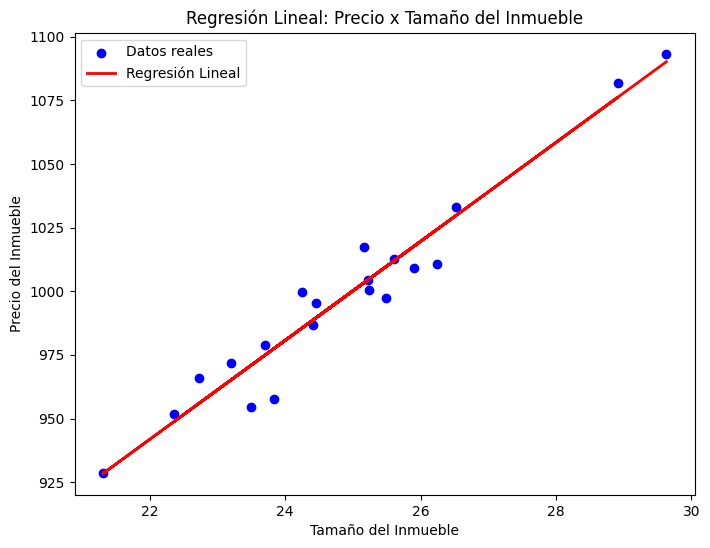

In [ ]:
# Importando bibliotecas
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Creando un conjunto de datos simulados
np.random.seed(42)
X = 2.5 * np.random.randn(100, 1) + 25  # Tamaño del inmueble (m2)
y = 500 + (X * 20) + np.random.randn(100, 1) * 10  # Precio del inmueble (miles de dólares)

# Definiendo features (independientes) y labels (dependient8es)
features = X
labels = y

# Dividiendo los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# Creando y entrenando el modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Modelo de Regresión lineal
# Y = A X + B
# Y -> Variable de salida
# X -> Tamaño del inmueble
# A y B son los coeficientes

# Coeficientes de Regresión
print(f"Coeficiente angular (b1): {model.coef_[0][0]:.2f}")
print(f"Intercepto (b0): {model.intercept_[0]:.2f}")

# Predicciones con los datos de prueba
y_pred = model.predict(X_test)

# Indicadores de la Evaluación del modelo con los datos de prueba
# R² Ajuste de los datos al modelo
r2 = r2_score(y_test, y_pred)
#MAE (Error Medio Absoluto)
mae = mean_absolute_error(y_test, y_pred)
#RMSE (Raíz del error Cuadrático Medio)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nMétricas de Evaluación:")
print(f"R² en datos de prueba: {r2:.2f}")
print(f"Erro Medio Absoluto (MAE): {mae:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")

# Evaluación cruzada
cv_scores = cross_val_score(model, features, labels, cv=5, scoring='r2')
print(f"\nPromedio de los puntajes de la validación cruzada: {cv_scores.mean():.2f}")

# Gráfico de la recta de Regresión
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color='blue', label='Datos reales')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regresión Lineal')
plt.xlabel("Tamaño del Inmueble")
plt.ylabel("Precio del Inmueble")
plt.title("Regresión Lineal: Precio x Tamaño del Inmueble")
plt.legend()
plt.show()

El codigo de arriba es regrecion lineal

Lo que hacemos es buscar la regla que mas se aproxime al conjunto de datos

#Entrenammiento de un modelo

Con datos del dataset iris

In [1]:
#Machine learning superbisado
import numpy as np #Para hacer operaciones con matrices y vectores
import pandas as pd #Manejo de datos usando tablas
from sklearn import datasets #Dataset de pruebas con datos limpios
from sklearn.model_selection import train_test_split, cross_val_score #Separo los datos del dataset en dos uno de entrenamiento y otros de prueba
from sklearn.tree import DecisionTreeClassifier #Importo el arbol de desiciones que funciona en base a preguntas
from sklearn.metrics import accuracy_score #Erramienta que mide el nivel de prediccion de la ia para ver que tan asertada es

# Cargar el dataset Iris de la biblioteca sklearn
dataset = datasets.load_iris()

# Convertir a DataFrame de Pandas para facilitar la manipulación de los datos
df = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
df['target'] = dataset.target  # Agregar la columna con las clases de las flores

# Separar los atributos (X) y las etiquetas (y)
X = df.iloc[:, :-1]  # Todas las columnas excepto la última
y = df['target']  # Última columna, que contiene las clases

# Dividir los datos en conjunto de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar un modelo de Árbol de Decisión
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Hacer predicciones en los datos de prueba
y_pred = model.predict(X_test)

# Evaluar el rendimiento del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión del modelo: {accuracy:.2f}')

# Aplicar validación cruzada para mejor evaluación del rendimiento
cross_val_scores = cross_val_score(model, X, y, cv=5)
print(f'Precisión media en la validación cruzada: {cross_val_scores.mean():.2f}')

# Probar con una nueva muestra
nueva_muestra = np.array([[5.1, 3.5, 1.4, 0.2]])  # Ejemplo de medidas de una flor
prediccion = model.predict(nueva_muestra)
print(f'Clase prevista para la nueva muestra: {dataset.target_names[prediccion[0]]}')

Precisión del modelo: 1.00
Precisión media en la validación cruzada: 0.95
Clase prevista para la nueva muestra: setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [8]:
#Machine learning superbisado
import numpy as np #Para hacer operaciones con matrices y vectores
import pandas as pd #Manejo de datos usando tablas
from sklearn import datasets #Dataset de pruebas con datos limpios
from sklearn.model_selection import train_test_split, cross_val_score #Separo los datos del dataset en dos uno de entrenamiento y otros de prueba
from sklearn.tree import DecisionTreeClassifier #Importo el arbol de desiciones que funciona en base a preguntas
from sklearn.metrics import accuracy_score #Erramienta que mide el nivel de prediccion de la ia para ver que tan asertada es

# Cargar el dataset Iris de la biblioteca sklearn
#Creo un objecto de Sklearn
dataset = datasets.load_iris()

#Le decimos al dataframe que tiene que guardar es decir le paso la info
#Que ira en data que seran las filas y luego paso la columnas como las llamaremos
df = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)

#Creo un columna llamada target y le meto info
df["target"] = dataset.target

# Separar los atributos (X) y las etiquetas (y)
X = df.iloc[:, :-1]  # Todas las columnas excepto la última
y = df['target']  # Última columna, que contiene las clases de las flores

#Donde me quede por entender
# Dividir los datos en conjunto de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [13]:
y_test

,target
73,1
18,0
118,2
78,1
76,1
31,0
64,1
141,2
68,1
82,1


#Clasificacion y Regrasion
